# 04 - Performance Analysis

This notebook reviews generated performance outputs, plots, robustness tables, and benchmark/subperiod diagnostics. It reads existing files produced by `python main.py`.

In [10]:
from pathlib import Path
import sys

from IPython.display import Image, display
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"
FIGURES = REPORTS / "figures"

def read_csv_if_exists(path, **kwargs):
    if path.exists():
        return pd.read_csv(path, **kwargs)
    print(f"Missing: {path}")
    return None

## Performance Summary

In [11]:
performance_summary = read_csv_if_exists(DATA_PROCESSED / "performance_summary.csv", index_col=0)
if performance_summary is not None:
    display(performance_summary)


,value
total_return,13.207742
annualized_return,0.277005
annualized_volatility,0.204964
sharpe_ratio,1.296311
max_drawdown,-0.329623
hit_ratio,0.575137
annualized_active_return,0.117115
tracking_error,0.053218
information_ratio,2.200677


## Existing Report Figures

nav_vs_benchmark.png


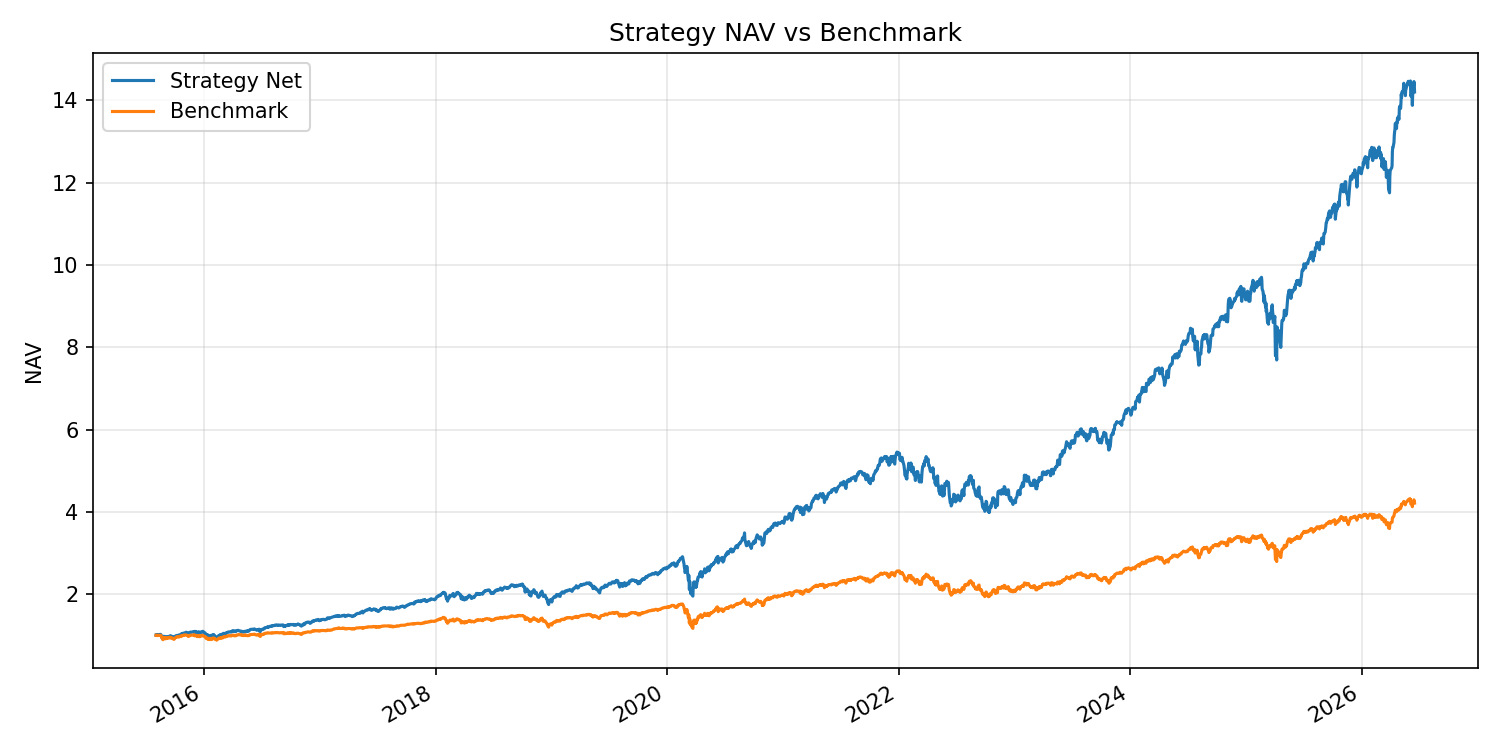

cumulative_active_return.png


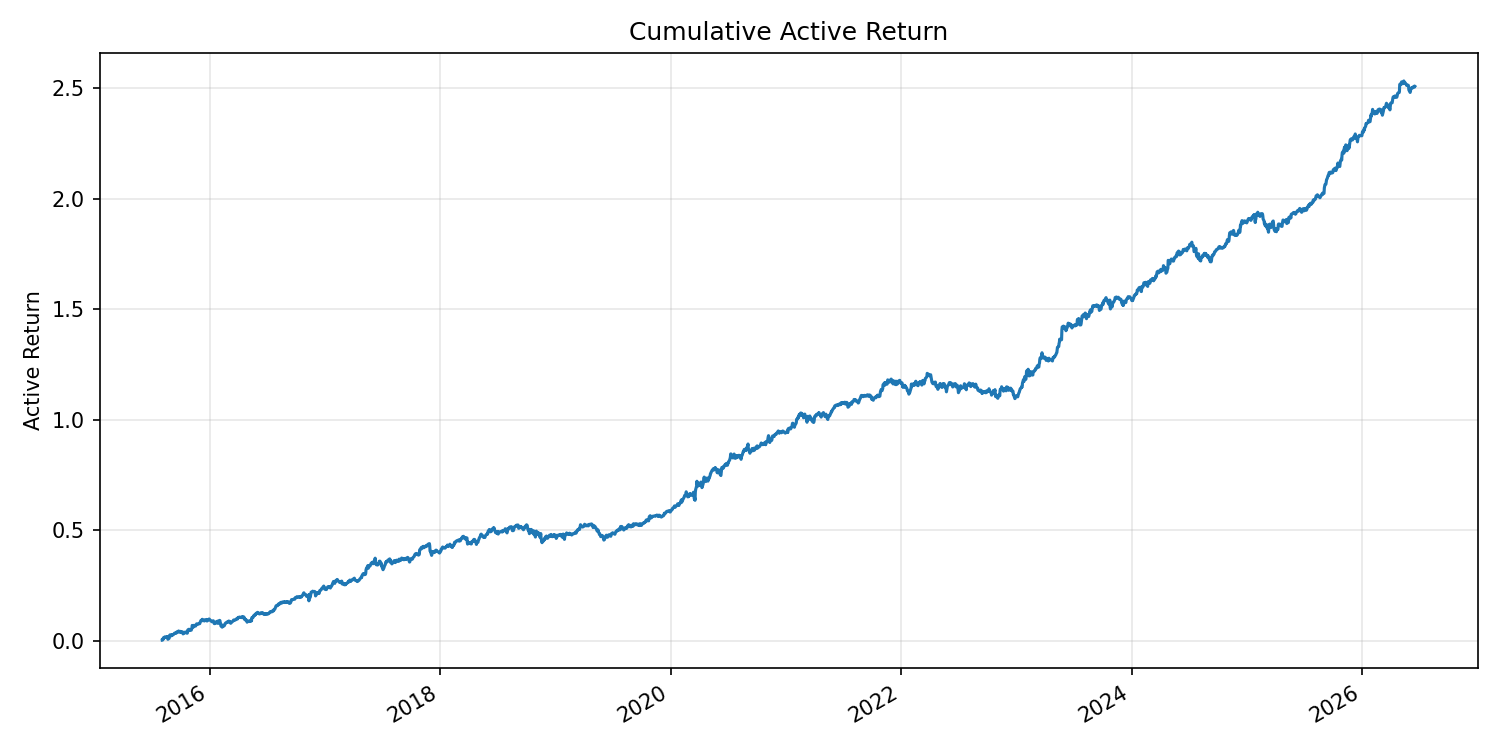

drawdown.png


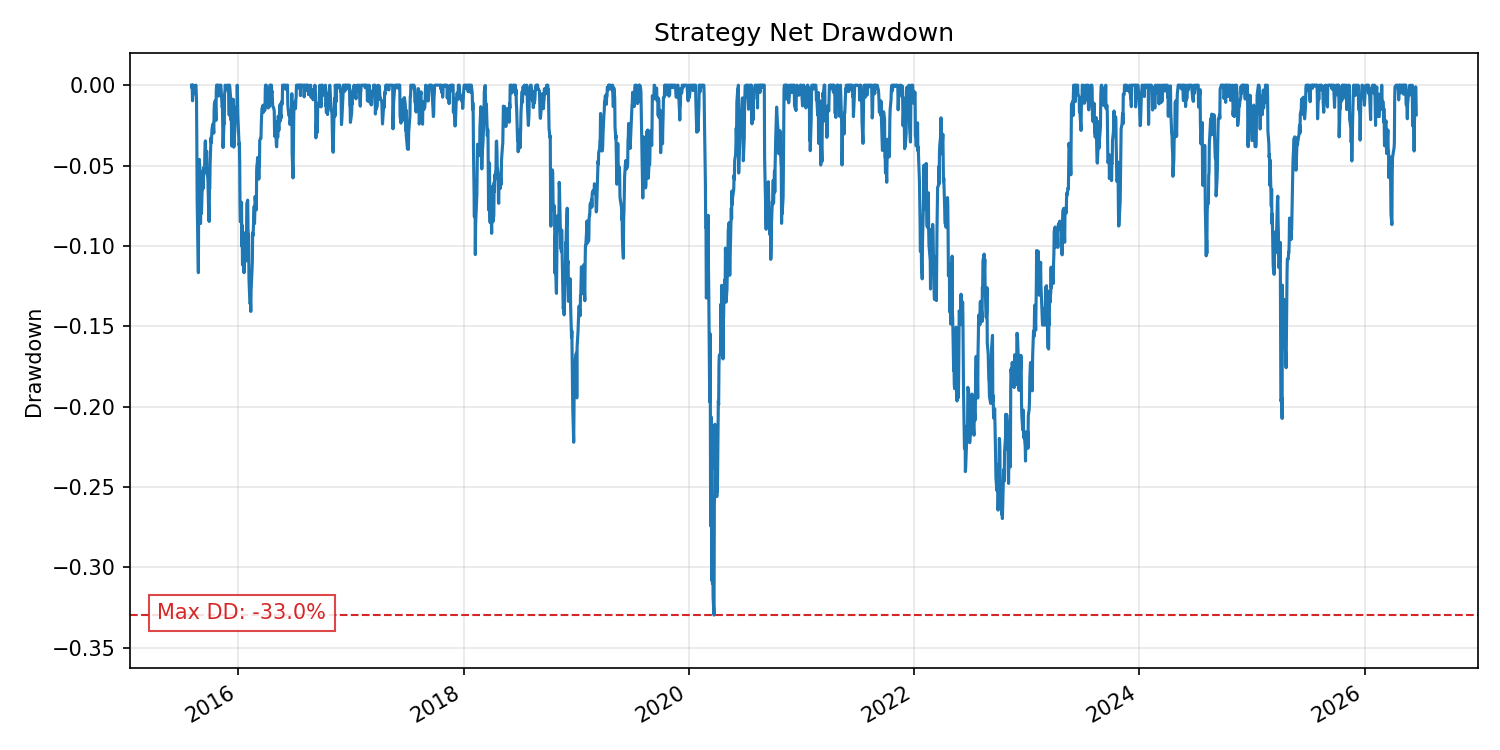

turnover.png


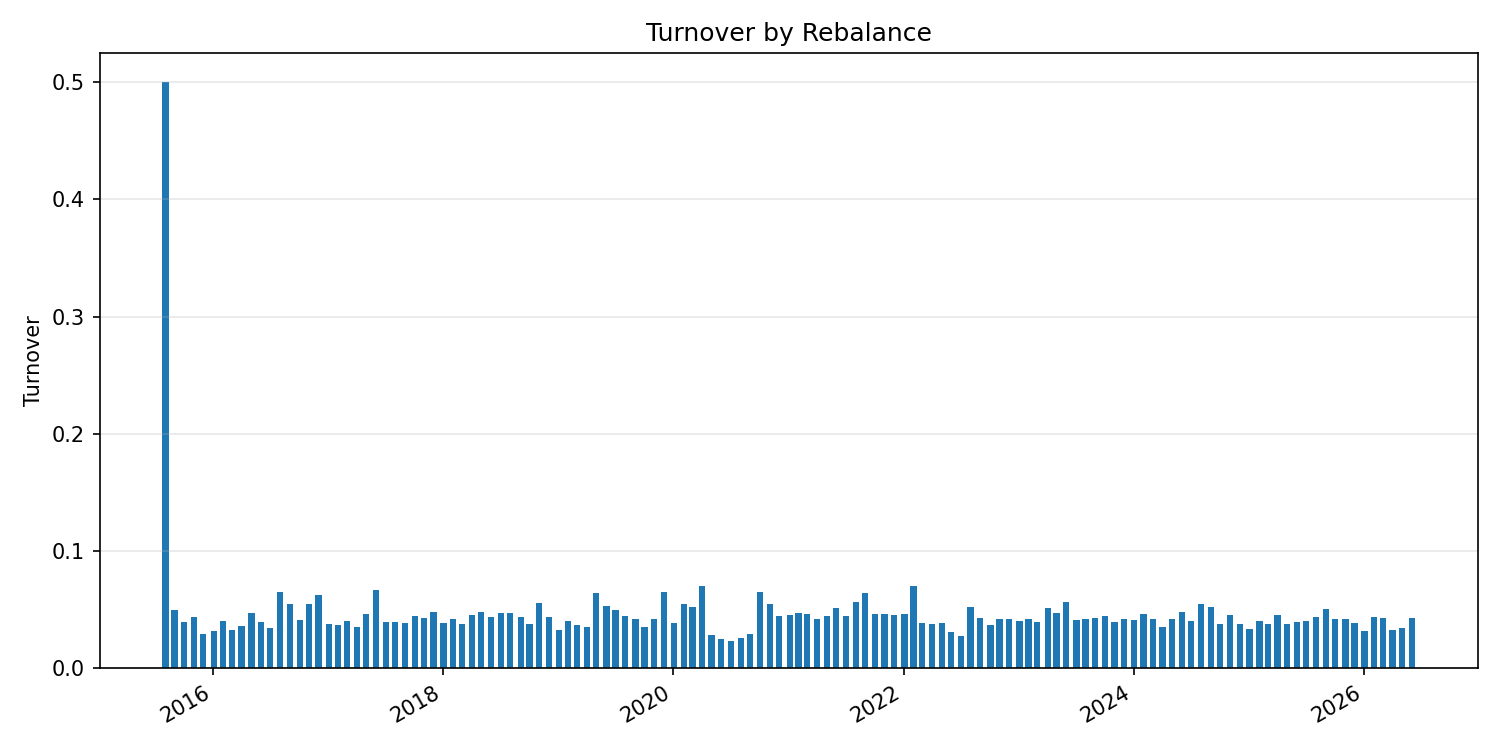

rolling_active_return.png


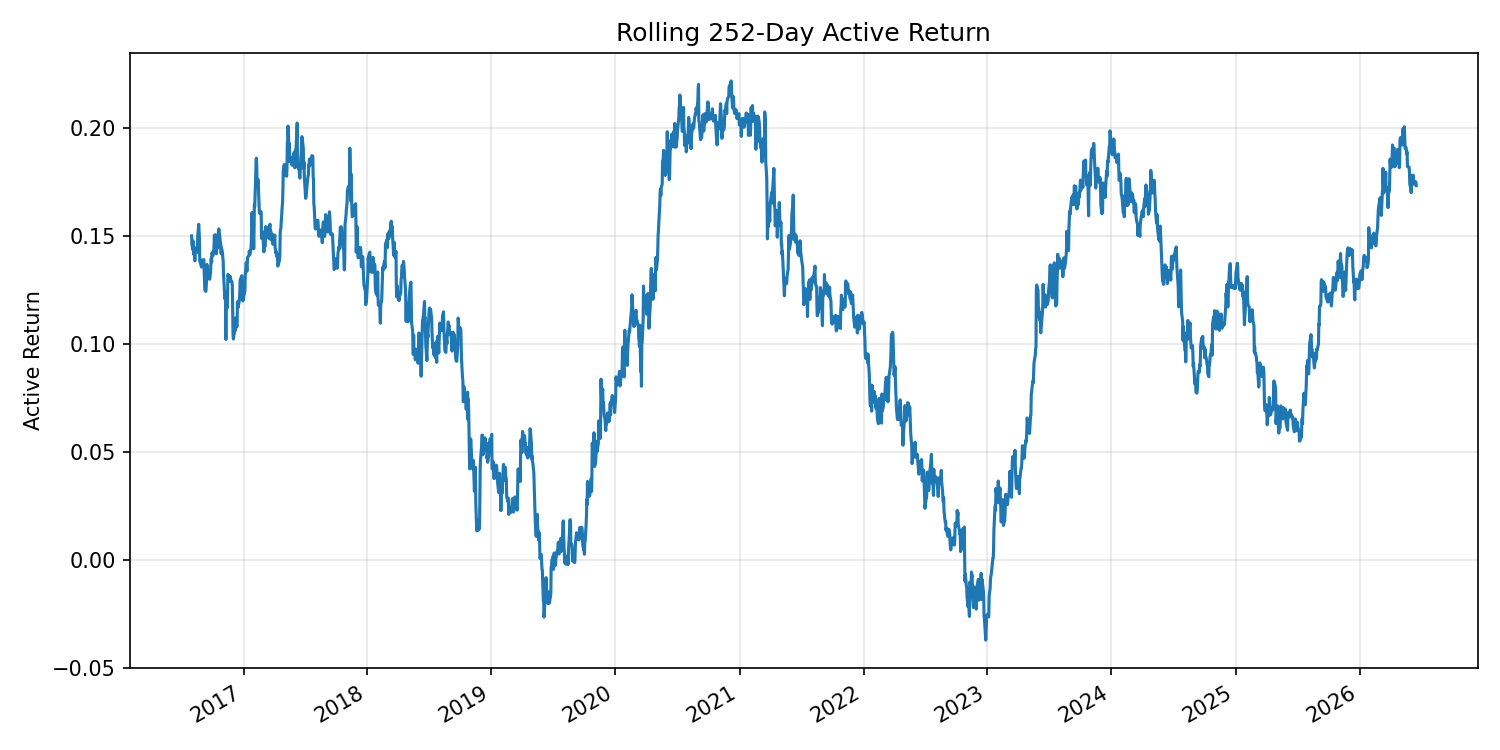

rolling_tracking_error.png


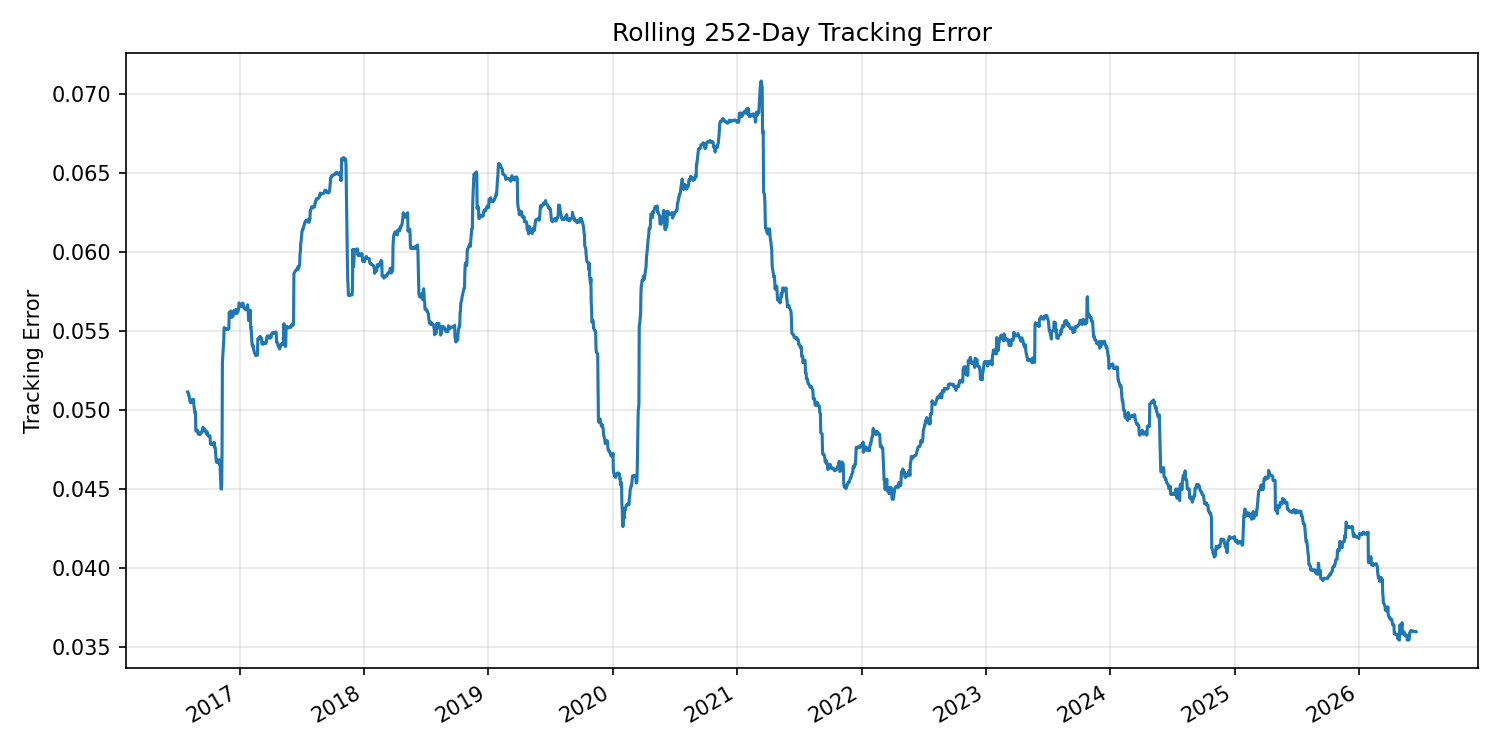

In [12]:
figure_names = [
    "nav_vs_benchmark.png",
    "cumulative_active_return.png",
    "drawdown.png",
    "turnover.png",
    "rolling_active_return.png",
    "rolling_tracking_error.png",
]

for figure_name in figure_names:
    path = FIGURES / figure_name
    if path.exists():
        print(figure_name)
        display(Image(filename=str(path)))
    else:
        print(f"Missing figure: {path}")

## Robustness Tables

In [13]:
cost_sensitivity = read_csv_if_exists(REPORTS / "cost_sensitivity.csv")
active_budget_sensitivity = read_csv_if_exists(REPORTS / "active_budget_sensitivity.csv")
subperiod_performance = read_csv_if_exists(REPORTS / "subperiod_performance.csv")
subperiod_by_benchmark = read_csv_if_exists(REPORTS / "subperiod_by_benchmark.csv")

for name, table in [
    ("Cost Sensitivity", cost_sensitivity),
    ("Active Budget Sensitivity", active_budget_sensitivity),
    ("Subperiod Performance", subperiod_performance),
    ("Subperiod by Benchmark", subperiod_by_benchmark),
]:
    if table is not None:
        print(name)
        display(table)

Cost Sensitivity


,cost_bps,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,hit_ratio,annualized_active_return,tracking_error,information_ratio,average_turnover,annualized_turnover
0,0.0,13.383211,0.278450,0.204965,1.301827,-0.329555,0.576600,0.118247,0.053222,2.221772,0.046904,0.562844
1,5.0,13.295211,0.277727,0.204965,1.299070,-0.329589,0.575503,0.117681,0.053219,2.211242,0.046904,0.562844
2,10.0,13.207742,0.277005,0.204964,1.296311,-0.329623,0.575137,0.117115,0.053218,2.200677,0.046904,0.562844
3,20.0,13.034385,0.275561,0.204964,1.290790,-0.329690,0.574406,0.115983,0.053217,2.179438,0.046904,0.562844


Active Budget Sensitivity


,active_budget,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,hit_ratio,annualized_active_return,tracking_error,information_ratio,average_turnover,annualized_turnover
0,0.1,13.322391,0.277951,0.206465,1.291964,-0.330720,0.574406,0.118163,0.053612,2.204029,0.028118,0.337415
1,0.2,13.207742,0.277005,0.204964,1.296311,-0.329623,0.575137,0.117115,0.053218,2.200677,0.046904,0.562844
2,0.3,13.040387,0.275611,0.203594,1.298303,-0.329483,0.575137,0.115744,0.052859,2.189688,0.062578,0.750939


Subperiod Performance


,period,start_date,end_date,num_observations,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,hit_ratio,annualized_active_return,tracking_error,information_ratio
0,2015_2019,2015-01-01,2019-12-31,1112,1.617144,0.243620,0.163980,1.412286,-0.222088,0.581835,0.105851,0.056483,1.874033
1,2020_2022,2020-01-01,2022-12-31,756,0.628612,0.176538,0.279036,0.723020,-0.329623,0.558201,0.096941,0.057289,1.692156
2,2023_latest,2023-01-01,NaN,867,2.333342,0.418989,0.173755,2.101861,-0.207284,0.581315,0.149153,0.044506,3.351306


Subperiod by Benchmark


,benchmark,period,start_date,end_date,num_observations,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,hit_ratio,annualized_active_return,tracking_error,information_ratio
0,SPY,2015_2019,2015-01-01,2019-12-31,1112,1.617144,0.243620,0.163980,1.412286,-0.222088,0.581835,0.105851,0.056483,1.874033
1,SPY,2020_2022,2020-01-01,2022-12-31,756,0.628612,0.176538,0.279036,0.723020,-0.329623,0.558201,0.096941,0.057289,1.692156
2,SPY,2023_latest,2023-01-01,NaN,867,2.333342,0.418989,0.173755,2.101861,-0.207284,0.581315,0.149153,0.044506,3.351306
3,EqualWeightUniverse,2015_2019,2015-01-01,2019-12-31,1112,1.617144,0.243620,0.163980,1.412286,-0.222088,0.581835,0.068456,0.066590,1.028015
4,EqualWeightUniverse,2020_2022,2020-01-01,2022-12-31,756,0.628612,0.176538,0.279036,0.723020,-0.329623,0.558201,0.037760,0.102753,0.367482
5,EqualWeightUniverse,2023_latest,2023-01-01,NaN,867,2.333342,0.418989,0.173755,2.101861,-0.207284,0.581315,0.172612,0.096511,1.788518


## Benchmark/Subperiod Information Ratio Pivot

In [14]:
if subperiod_by_benchmark is not None:
    ir_pivot = subperiod_by_benchmark.pivot(
        index="period",
        columns="benchmark",
        values="information_ratio",
    )
    active_return_pivot = subperiod_by_benchmark.pivot(
        index="period",
        columns="benchmark",
        values="annualized_active_return",
    )

    print("Information ratio by benchmark and subperiod")
    display(ir_pivot)

    print("Annualized active return by benchmark and subperiod")
    display(active_return_pivot)

Information ratio by benchmark and subperiod


benchmark,EqualWeightUniverse,SPY
period,,
2015_2019,1.028015,1.874033
2020_2022,0.367482,1.692156
2023_latest,1.788518,3.351306


Annualized active return by benchmark and subperiod


benchmark,EqualWeightUniverse,SPY
period,,
2015_2019,0.068456,0.105851
2020_2022,0.037760,0.096941
2023_latest,0.172612,0.149153


## Version 1.2 Momentum Backtest Sensitivity

This table compares full backtest results for momentum lookback/skip specifications. Unlike IC sensitivity, this includes portfolio construction, transaction costs, benchmark weights, and turnover.

In [15]:
momentum_backtest = read_csv_if_exists(REPORTS / "momentum_backtest_sensitivity.csv")
if momentum_backtest is not None:
    momentum_backtest = momentum_backtest.copy()
    momentum_backtest["spec"] = momentum_backtest["lookback_days"].astype(str) + "-" + momentum_backtest["skip_days"].astype(str)
    display(momentum_backtest.sort_values("information_ratio", ascending=False))

,lookback_days,skip_days,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,hit_ratio,annualized_active_return,tracking_error,information_ratio,average_turnover,annualized_turnover,spec
2,126,0,13.829397,0.282053,0.207144,1.303912,-0.330816,0.573309,0.121516,0.055359,2.195046,0.048709,0.584504,126-0
0,63,0,13.975412,0.275915,0.204336,1.295490,-0.326908,0.571633,0.118079,0.054173,2.179662,0.068691,0.824292,63-0
3,126,21,13.528225,0.279632,0.208423,1.288107,-0.336198,0.575503,0.119889,0.055890,2.145064,0.054108,0.649299,126-21
4,189,0,13.142407,0.283950,0.206766,1.313083,-0.328400,0.577312,0.119234,0.055910,2.132613,0.040424,0.485086,189-0
1,63,21,13.501996,0.272231,0.205895,1.273181,-0.333488,0.571633,0.115505,0.054781,2.108504,0.085088,1.021051,63-21
5,189,21,12.996085,0.282691,0.207842,1.302630,-0.331551,0.577312,0.118475,0.056334,2.103058,0.043145,0.517742,189-21
6,252,0,13.481132,0.294427,0.207087,1.350646,-0.328316,0.576628,0.118007,0.056122,2.102691,0.035583,0.427000,252-0
7,252,21,13.366026,0.293430,0.208068,1.341546,-0.331145,0.577011,0.117438,0.056506,2.078331,0.037002,0.444026,252-21


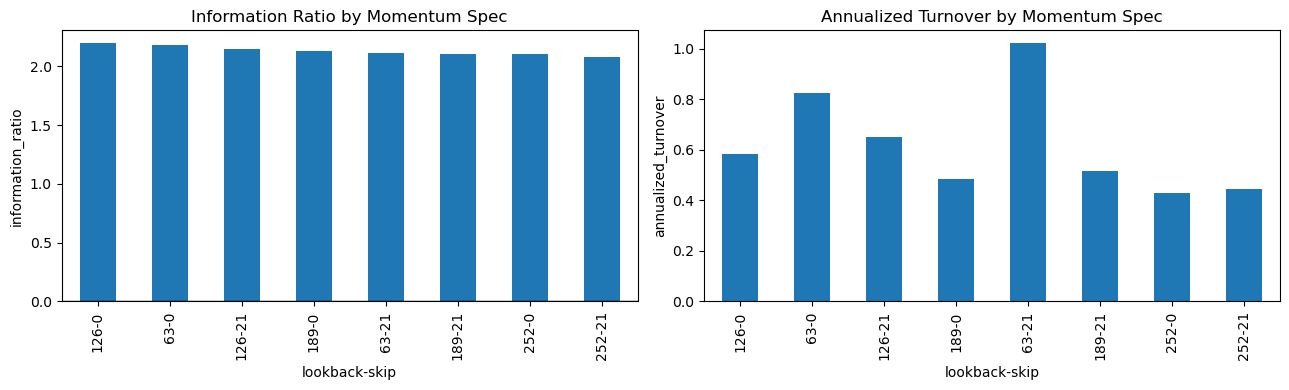

In [16]:
import matplotlib.pyplot as plt

if momentum_backtest is not None:
    sorted_momentum = momentum_backtest.sort_values("information_ratio", ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    sorted_momentum.plot(x="spec", y="information_ratio", kind="bar", ax=axes[0], legend=False, title="Information Ratio by Momentum Spec")
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_xlabel("lookback-skip")
    axes[0].set_ylabel("information_ratio")

    sorted_momentum.plot(x="spec", y="annualized_turnover", kind="bar", ax=axes[1], legend=False, title="Annualized Turnover by Momentum Spec")
    axes[1].set_xlabel("lookback-skip")
    axes[1].set_ylabel("annualized_turnover")

    plt.tight_layout()
    plt.show()

In the current run, 126-0 momentum has the highest information ratio, while 252-day momentum variants have lower turnover. This supports using 6-month no-skip momentum as the current default candidate, but the result should remain provisional. The `market_cap_static` benchmark mode uses current market caps, so historical performance still carries look-ahead bias.

## Version 1.3 Alpha Model Sensitivity

This table compares the configurable alpha models introduced in Version 1.3. It helps separate raw factor availability from the final alpha-score design used by portfolio construction.

In [17]:
alpha_model_sensitivity = read_csv_if_exists(REPORTS / "alpha_model_sensitivity.csv")
alpha_model_columns = [
    "alpha_model",
    "annualized_active_return",
    "tracking_error",
    "information_ratio",
    "max_drawdown",
    "annualized_turnover",
    "average_active_share",
    "max_active_share",
    "max_absolute_active_weight",
]

if alpha_model_sensitivity is not None:
    alpha_model_compact = alpha_model_sensitivity.loc[:, alpha_model_columns]
    display(alpha_model_compact.sort_values("information_ratio", ascending=False).reset_index(drop=True))

,alpha_model,annualized_active_return,tracking_error,information_ratio,max_drawdown,annualized_turnover,average_active_share,max_active_share,max_absolute_active_weight
0,risk_adjusted_momentum,0.117115,0.053218,2.200677,-0.329623,0.562844,0.092262,0.107989,0.00499
1,momentum_only,0.121516,0.055359,2.195046,-0.330816,0.584504,0.093945,0.110524,0.00499
2,momentum_reversal,0.121054,0.055595,2.177434,-0.332710,0.555025,0.093935,0.110097,0.00499
3,equal_weight_composite,0.109577,0.050864,2.154296,-0.333374,0.554150,0.090659,0.104088,0.00499


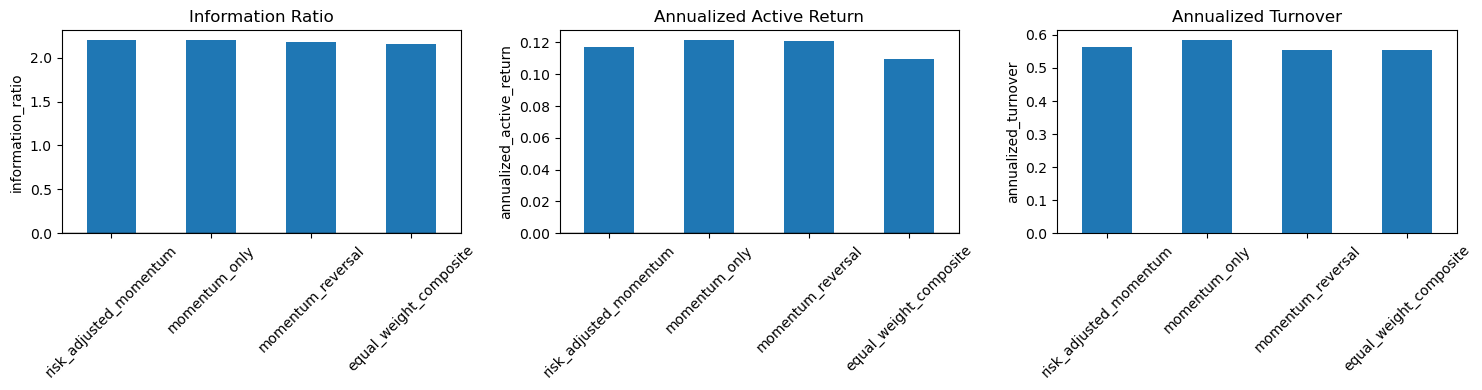

In [18]:
import matplotlib.pyplot as plt

if alpha_model_sensitivity is not None:
    sorted_alpha = alpha_model_sensitivity.sort_values("information_ratio", ascending=False)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    sorted_alpha.plot(x="alpha_model", y="information_ratio", kind="bar", ax=axes[0], legend=False, title="Information Ratio")
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_xlabel("")
    axes[0].set_ylabel("information_ratio")

    sorted_alpha.plot(x="alpha_model", y="annualized_active_return", kind="bar", ax=axes[1], legend=False, title="Annualized Active Return")
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set_xlabel("")
    axes[1].set_ylabel("annualized_active_return")

    sorted_alpha.plot(x="alpha_model", y="annualized_turnover", kind="bar", ax=axes[2], legend=False, title="Annualized Turnover")
    axes[2].set_xlabel("")
    axes[2].set_ylabel("annualized_turnover")

    for ax in axes:
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

In the current alpha model sensitivity run, `momentum_only` has the highest active return, while `risk_adjusted_momentum` has the highest information ratio and slightly lower drawdown. The difference is small, so both remain primary candidates. `risk_adjusted_momentum` is selected as the current default because Version 1 emphasizes risk-controlled index enhancement rather than simply maximizing active return. All results remain subject to static market-cap look-ahead bias and survivorship bias.

## Performance Interpretation

Use the robustness tables together rather than focusing on one headline number. The current framework is useful because it exposes how results change under transaction costs, active budget choices, factor mixes, subperiods, and benchmark definitions.

Important limitations remain:

- Static current constituents introduce survivorship bias.
- Static current market-cap benchmark weights introduce look-ahead bias.
- Results depend strongly on benchmark construction.
- Factor IC evidence is weak overall, so apparent portfolio performance should be interpreted cautiously.
- The next research step is to compare the original 12-1 momentum setting against the stronger IC candidate, 6-month no-skip momentum, in a full backtest sensitivity.